
# Aim of Notebook: BTS Reader-Insert Fanfiction Data Preprocessing 
The aim of this notebook is to construct a cleaned BTS reader-insert fanfiction corpus suitable for tag co-occurrence network analysis.

The preprocessing workflow consists of three main stages:

1. **Corpus Exploration and Data Cleaning:** Descriptive statistics were used to examine corpus composition and guide preprocessing decisions regarding which records to retain or exclude.

2. **Canonical Tag Extraction:** AO3’s canonical tag list was used to identify and normalize canonical tags within the corpus, producing a consistent tag vocabulary for subsequent tag co-occurrence analysis.

3. **Tag Separation and Rating Classification:** Canonical tags were separated from non-canonical tags. Canonical tags were used to construct tag co-occurrence networks, while non-canonical tags, particularly BTS member-specific tags, were retained to examine character archetypes and member-associated patterns in reader-insert fanfiction genres and tropes. Tag frequencies were examined across rating categories before constructing rating-specific co-occurrence networks. Works without tags were retained in the corpus but excluded from co-occurrence calculations.


## 1. Setting up Notebook Environment

Initalizing global imports used in this notebook and setting up necessary project paths so the notebook works on any machine cloned from GitHub.

In [1]:
# System utilities and project path handling

import re
import sys
from collections import Counter
from pathlib import Path

# Data handling

import numpy as np
import pandas as pd

# Statistical analysis

from scipy.stats import gaussian_kde, skew

# Visualization

import matplotlib.pyplot as plt
import plotly.graph_objects as go
from wordcloud import WordCloud

# Notebook display

from IPython.display import Markdown, display

D:\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
# Project paths

PROJECT_ROOT = Path().resolve().parent

NOTEBOOKS_PATH = PROJECT_ROOT / "notebooks"
SCRIPTS_PATH = PROJECT_ROOT / "scripts"

DATA_DIR = PROJECT_ROOT / "data"
METADATA_DIR = DATA_DIR / "metadata"

FICS_DIR = DATA_DIR / "bts_fics"
FIN_DIR = FICS_DIR / "final"

CLEAN_DIR = DATA_DIR / "cleaned"
CLEAN_FICS_PATH = CLEAN_DIR / "fics"

REPORTS_PATH = PROJECT_ROOT / "reports"
FICS_REPORTS_PATH = REPORTS_PATH / "fics_reports"
FICS_FIGURES_PATH = REPORTS_PATH / "fics_figures"


# Create project directories if they do not exist

for path in [
    NOTEBOOKS_PATH,
    SCRIPTS_PATH,
    DATA_DIR,
    METADATA_DIR,
    FICS_DIR,
    FIN_DIR,
    CLEAN_DIR,
    CLEAN_FICS_PATH,
    REPORTS_PATH,
    FICS_REPORTS_PATH,
    FICS_FIGURES_PATH,
]:
    path.mkdir(
        parents=True,
        exist_ok=True
    )


# Check project structure

print("Project root is:", PROJECT_ROOT)
print("Notebooks folder exists:", NOTEBOOKS_PATH.exists())
print("Scripts folder exists:", SCRIPTS_PATH.exists())
print("Data folder exists:", DATA_DIR.exists())
print("Metadata folder exists:", METADATA_DIR.exists())
print("BTS fics folder exists:", FICS_DIR.exists())
print("Final fics folder exists:", FIN_DIR.exists())
print("Cleaned data folder exists:", CLEAN_DIR.exists())
print("Cleaned fics folder exists:", CLEAN_FICS_PATH.exists())
print("Reports folder exists:", REPORTS_PATH.exists())
print("Fics reports folder exists:", FICS_REPORTS_PATH.exists())
print("Fics figures folder exists:", FICS_FIGURES_PATH.exists())

Project root is: E:\Jupyter_Programs\DH_Thesis
Notebooks folder exists: True
Scripts folder exists: True
Data folder exists: True
Metadata folder exists: True
BTS fics folder exists: True
Final fics folder exists: True
Cleaned data folder exists: True
Cleaned fics folder exists: True
Reports folder exists: True
Fics reports folder exists: True
Fics figures folder exists: True


## 2. Dataset Loading Utilities 

To load the combined all bts member fics dataset and as also simultaenously load the per member fic dataset as well

In [3]:
def load_file(file_path: Path) -> pd.DataFrame:
    """Load a combined fanfiction dataset."""
    return pd.read_csv(file_path)


def load_member_dfs(
    directory: Path,
    pattern="*_final_fics.csv"
):
    """Load per-member fanfiction datasets into a dictionary."""

    member_dfs = {}

    for file in directory.glob(pattern):

        # Exclude the combined dataset
        if file.name == "bts_final_all_fics.csv":
            continue

        member = file.stem.replace(
            "_final_fics",
            ""
        )

        member_dfs[member] = pd.read_csv(file)

    return member_dfs




In [4]:
# Load combined dataset
fics = load_file(
    FIN_DIR / "bts_final_all_fics.csv"
)

# Load member-specific datasets
member_dfs = load_member_dfs(
    FIN_DIR
)


print("Main dataset shape:", fics.shape)
print("Members loaded:", list(member_dfs.keys()))

Main dataset shape: (7414, 14)
Members loaded: ['hoseok', 'jimin', 'jungkook', 'namjoon', 'seokjin', 'taehyung', 'yoongi']


## 3. Data Cleaning: Remove Columns & Establish a Unique Identifier 

Ensure consistent IDs and remove duplicate records (if any) and redundant columns in the bts fanfiction corpora. 

---



In [5]:
# Check how many columns are fully unique
uniqueness = fics.nunique().sort_values(ascending=False)
print("Top uniqueness counts:")
print(uniqueness.head(10))

Top uniqueness counts:
s                7414
summary          7088
title            6975
keyword          6731
words            5167
datePublished    2148
relationship     2110
kudos             472
member              7
members_found       7
dtype: int64


In [6]:
# Explicit check: is s truly unique?
id_col = "s"

print("Main dataset shape:", fics.shape)

print("Total rows:", len(fics))
print("Unique row_number values:", fics[id_col].nunique())
print("Duplicate row_number entries:", fics[id_col].duplicated().sum())

Main dataset shape: (7414, 14)
Total rows: 7414
Unique row_number values: 7414
Duplicate row_number entries: 0


#### Data Cleaning Decision: Establish Unique ID
Since total count of records in column ``s`` is equal to total rows of the database that is 7414. The ``s`` column was used as the primary identifier because it is a unique  reference from GOLEM database from where this data is acquired.  This makes it suitable for aligning records across preprocessing steps


In [7]:
fics.columns

Index(['s', 'kudos', 'title', 'summary', 'datePublished', 'words', 'rating',
       'romanticCategory', 'publicationStatus', 'keyword', 'relationship',
       'polyship_human_flag', 'member', 'members_found'],
      dtype='str')

#### Data Cleaning Decision: Remove members_found column
`members_found` was a redundant column created for a corpus acquisition task that is now being removed from the corpora. Anyway, it was similar to members column and has no use for this corpora. 


In [8]:
#remove members_found
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
fics = fics.drop(columns="members_found", errors="ignore")

In [9]:
fics.columns

Index(['s', 'kudos', 'title', 'summary', 'datePublished', 'words', 'rating',
       'romanticCategory', 'publicationStatus', 'keyword', 'relationship',
       'polyship_human_flag', 'member'],
      dtype='str')

## 4. Exploratory Data Analysis and Corpus Filtering

In [10]:
fics.shape

(7414, 13)

In [11]:
#function to save data viz during EDA
def save_plotly_figure(fig, filename, output_dir):
    """
    Save a Plotly figure as HTML and PNG if the files do not already exist.
    """

    html_path = output_dir / f"{filename}.html"
    png_path = output_dir / f"{filename}.png"

    # Save HTML
    if html_path.exists():

        print(
            f"HTML figure already exists: {html_path}"
        )

    else:

        fig.write_html(
            html_path,
            include_plotlyjs="cdn"
        )

        print(
            f"Saved HTML figure: {html_path}"
        )

    # Save PNG
    if png_path.exists():

        print(
            f"PNG figure already exists: {png_path}"
        )

    else:

        fig.write_image(
            png_path,
            format="png",
            scale=3
        )

        print(
            f"Saved PNG figure: {png_path}"
        )

### 4.1 Summary Distribution

In [12]:
def tokenize(text):
    if pd.isna(text):
        return []
    return re.findall(r"\b\w+\b", str(text).lower())


def text_length_stats(df, columns):
    
    results = {}
    
    for col in columns:
        # tokenized documents
        tokens = df[col].fillna("").apply(tokenize)
        
        lengths = tokens.apply(len)
        
        all_tokens = [
            token 
            for doc in tokens 
            for token in doc
        ]
        
        stats = {
            "Number of documents": len(df),
            "Total tokens": len(all_tokens),
            "Vocabulary size": len(set(all_tokens)),
            "Mean words per document": lengths.mean(),
            "Median words per document": lengths.median(),
            "Standard deviation": lengths.std(),
            "Minimum": lengths.min(),
            "25th percentile": lengths.quantile(0.25),
            "50th percentile": lengths.quantile(0.50),
            "75th percentile": lengths.quantile(0.75),
            "Maximum": lengths.max(),
            "Skewness": skew(lengths)
        }
        
        results[col] = stats
        
        # add length column for plotting
        df[f"{col}_length"] = lengths
    
    return pd.DataFrame(results).T


columns = [
    "summary",
]

stats_table = text_length_stats(fics, columns)


SUMMARY_TOKEN_REPORT = (
    FICS_REPORTS_PATH /
    "02_summary_tokendis.md"
)

# Transpose statistics table so statistics are rows
summary_stats = stats_table.loc["summary"].round(2)

summary_stats_df = pd.DataFrame({
    "Statistic": summary_stats.index,
    "Value": summary_stats.values
})

markdown_table = summary_stats_df.to_markdown(
    index=False
)

markdown_content = f"""# Summary Token Distribution

Descriptive statistics for the token distribution of the `summary` field
in the BTS reader-insert fanfiction corpus.

{markdown_table}
"""

# Save only if the report does not already exist
if SUMMARY_TOKEN_REPORT.exists():

    print(
        f"Summary token distribution report already exists: "
        f"{SUMMARY_TOKEN_REPORT}"
    )

else:

    SUMMARY_TOKEN_REPORT.write_text(
        markdown_content,
        encoding="utf-8"
    )

    print(
        f"Saved summary token distribution report: "
        f"{SUMMARY_TOKEN_REPORT}"
    )

# Display report
display(
    Markdown(markdown_content)
)

Summary token distribution report already exists: E:\Jupyter_Programs\DH_Thesis\reports\fics_reports\02_summary_tokendis.md


# Summary Token Distribution

Descriptive statistics for the token distribution of the `summary` field
in the BTS reader-insert fanfiction corpus.

| Statistic                 |     Value |
|:--------------------------|----------:|
| Number of documents       |   7414    |
| Total tokens              | 282277    |
| Vocabulary size           |  14321    |
| Mean words per document   |     38.07 |
| Median words per document |     28    |
| Standard deviation        |     34.54 |
| Minimum                   |      0    |
| 25th percentile           |     14    |
| 50th percentile           |     28    |
| 75th percentile           |     51    |
| Maximum                   |    321    |
| Skewness                  |      1.99 |


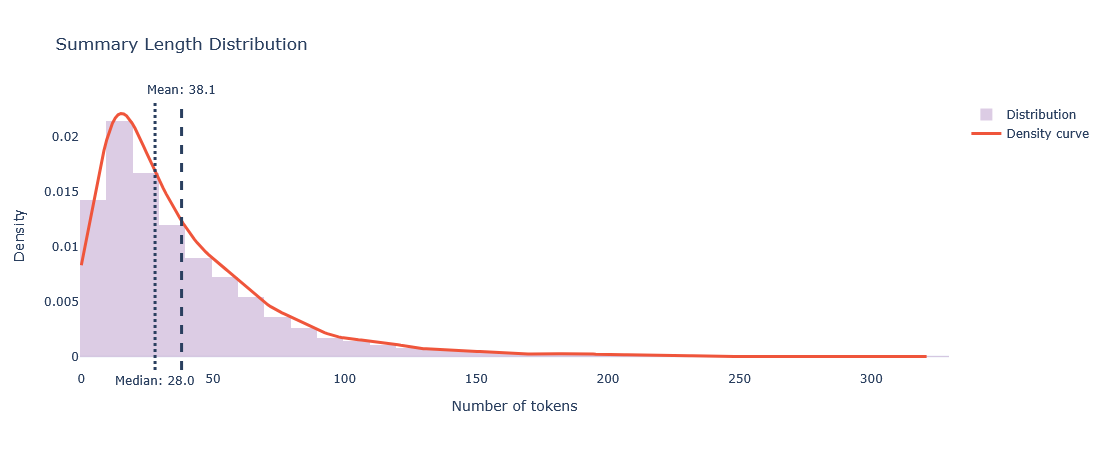

HTML figure already exists: E:\Jupyter_Programs\DH_Thesis\reports\fics_figures\03_summary_distribution.html
PNG figure already exists: E:\Jupyter_Programs\DH_Thesis\reports\fics_figures\03_summary_distribution.png


In [13]:
data = fics["summary_length"].dropna()

mean_val = data.mean()
median_val = data.median()

# KDE curve
kde = gaussian_kde(data)

x_range = np.linspace(
    data.min(),
    data.max(),
    300
)

density = kde(x_range) * 1.12
fig = go.Figure()

# Histogram (density)
fig.add_trace(
    go.Histogram(
        x=data,
        nbinsx=50,
        histnorm="probability density",
        marker=dict(
            color="#cab2d6"
        ),
        opacity=0.65,
        name="Distribution"
    )
)

# KDE curve
fig.add_trace(
    go.Scatter(
        x=x_range,
        y=density,
        mode="lines",
        line=dict(
            width=3
        ),
        name="Density curve"
    )
)

# Mean
fig.add_vline(
    x=mean_val,
    line_width=3,
    line_dash="dash",
    annotation_text=f"Mean: {mean_val:.1f}",
    annotation_position="top"
)

# Median
fig.add_vline(
    x=median_val,
    line_width=3,
    line_dash="dot",
    annotation_text=f"Median: {median_val:.1f}",
    annotation_position="bottom"
)

fig.update_layout(
    title="Summary Length Distribution",
    xaxis_title="Number of tokens",
    yaxis_title="Density",
    template="plotly_white",
    height=450,
    width=1000,
    bargap=0,
    showlegend=True
)

fig.update_xaxes(
    showgrid=False,
    showline=False
)

fig.update_yaxes(
    showgrid=False,
    showline=False
)

fig.show()

save_plotly_figure(
    fig,
    "03_summary_distribution",
    FICS_FIGURES_PATH
)

#### Data Method Decision Reconsidered! 

My first instinct was to approach fanfiction summaries through the same computational lens I applied to bot descriptions and greetings: could semantic clustering help trace genre conventions within this fan storytelling practice? However, summaries introduced a different kind of textual environment. Unlike bot descriptions and greetings, functioning as relatively structured prompts designed to refine and calibrate chatbot personas, summaries are much more unpredictable forms of fan-created metadata. They occupy a liminal space between the fictional world of the story and the social world of the fan community (Leavenworth 2015). Summaries were not simply spaces for describing a fic’s premise; they also contained fragments of author notes, prompt inspirations, shoutouts, requests for engagement, and even links to authors’ social media. This mosaic of diegetic storytelling and non-diegetic author commentary made summaries difficult to treat as consistent textual representations for sentence embeddings. 

The challenge was further compounded by their uneven token distribution: while some authors summarized an entire premise in a single sentence, others provided lengthy descriptions. Manually cleaning summaries was neither feasible at this scale nor methodologically appropriate, as it risked reducing an already limited metadata field.

### 4.2 Publication Status

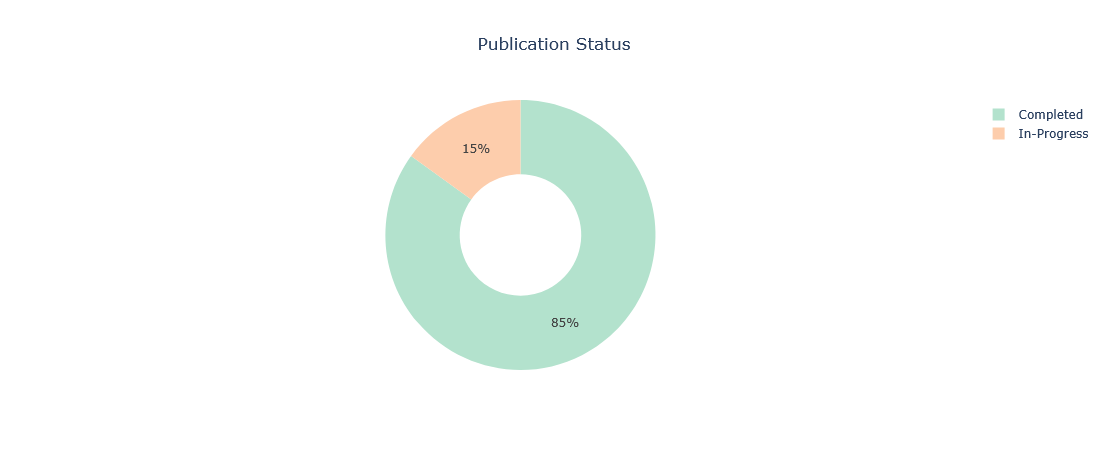

HTML figure already exists: E:\Jupyter_Programs\DH_Thesis\reports\fics_figures\04_pub_status.html
PNG figure already exists: E:\Jupyter_Programs\DH_Thesis\reports\fics_figures\04_pub_status.png


In [14]:
status_counts = (
    fics["publicationStatus"]
    .value_counts()
    .reset_index()
)

status_counts.columns = ["Status", "Count"]

status_counts["Percentage"] = (
    status_counts["Count"] / len(fics) * 100
)

publication_colors = [
    "#b3e2cd",
    "#fdcdac"
]

fig = go.Figure(
    go.Pie(
        labels=status_counts["Status"],
        values=status_counts["Percentage"],
        hole=0.45,
        textinfo="percent",
        textposition="inside",
        marker=dict(colors=publication_colors),
        hovertemplate="%{label}<br>%{value:.1f}% of corpus<extra></extra>",
        showlegend=True
    )
)

fig.update_layout(
    template="plotly_white",
    title=dict(
        text="Publication Status",
        x=0.5
    ),
    width=550,
    height=450,
    font=dict(size=12)
)

fig.show()

save_plotly_figure(
    fig,
    "04_pub_status",
    FICS_FIGURES_PATH
)

#### Data Cleaning Decision: Retain Both In-Progress and Completed Works 

Completed and work-in-progress fanfictions were both retained because publication status does not affect the semantic structure of author-assigned tags, which are typically applied when a work is first posted


### 4.3 Rating Distribution

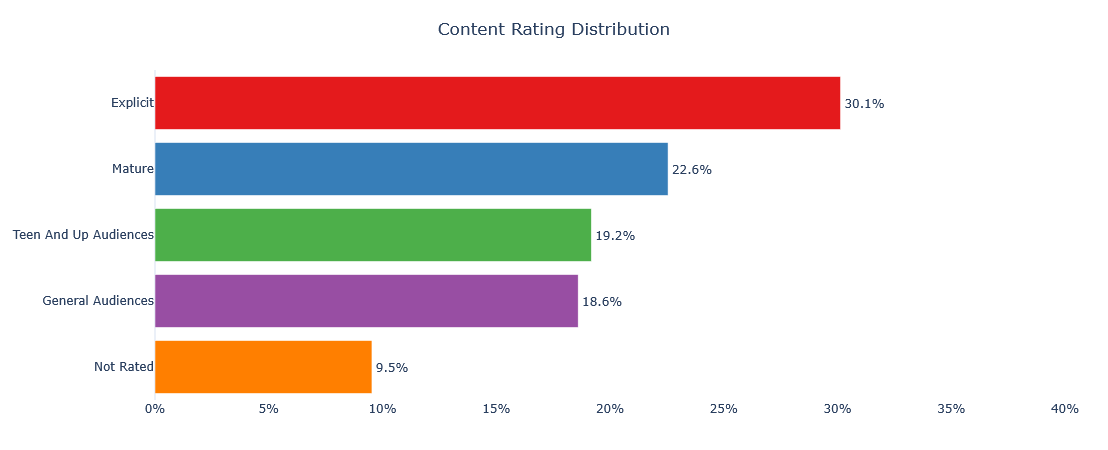

HTML figure already exists: E:\Jupyter_Programs\DH_Thesis\reports\fics_figures\05_rating_distribution.html
PNG figure already exists: E:\Jupyter_Programs\DH_Thesis\reports\fics_figures\05_rating_distribution.png


In [15]:
rating_counts = (
    fics["rating"]
    .value_counts()
    .reset_index()
)


rating_counts.columns = ["Rating", "Count"]

rating_counts["Percentage"] = (
    rating_counts["Count"] / len(fics) * 100
)

rating_counts = rating_counts.sort_values(
    "Percentage",
    ascending=True
)

rating_colors = [
    "#ff7f00",
    "#984ea3",
    "#4daf4a",
    "#377eb8",
"#e41a1c"
]



fig = go.Figure(
    go.Bar(
        y=rating_counts["Rating"],
        x=rating_counts["Percentage"],
        orientation="h",
        marker=dict(
            color=rating_colors[:len(rating_counts)]
        ),
        text=[
            f"{x:.1f}%"
            for x in rating_counts["Percentage"]
        ],
        textposition="outside",
        hovertemplate="%{y}<br>%{x:.1f}% of corpus<extra></extra>",
    )
)

fig.update_layout(
    template="plotly_white",
    title=dict(
        text="Content Rating Distribution",
        x=0.5
    ),
    width=700,
    height=450,
    margin=dict(
        l=140,
        r=40,
        t=70,
        b=50
    ),
    font=dict(size=12)
)

fig.update_xaxes(
    showgrid=False,
    showline=False,
    ticksuffix="%",
    range=[0, max(rating_counts["Percentage"]) + 10]
)

fig.update_yaxes(
    showgrid=False,
    showline=False,
    categoryorder="array",
    categoryarray=rating_counts["Rating"]
)

fig.show()

save_plotly_figure(
    fig,
    "05_rating_distribution",
    FICS_FIGURES_PATH
)

#### Data Cleaning Decision: Remove Not Rated Records

`Not Rated` records accounted for 9.5% of the corpus. Since ratings function as an important contextual variable in the analysis and can correlate with differences in genre conventions in tagging practices, unrated works could not be reliably assigned to a comparable and would reduce the interpretability of rating-specific network structures.

In [16]:

print("Count with Not Rated Fics:", len(fics))


fics = fics[fics["rating"] != "Not Rated"].copy()

print("Count after Removing Not Rated Fics:", len(fics))

Count with Not Rated Fics: 7414
Count after Removing Not Rated Fics: 6707


### 4.4 Polyship Distribution

Checking manually annotated polyships with readers

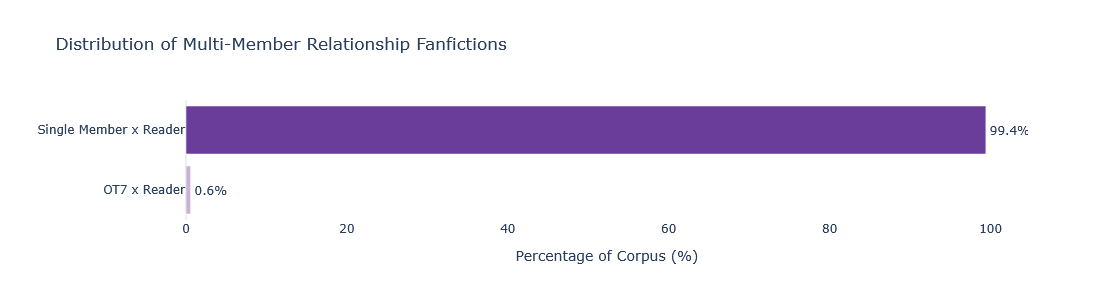

HTML figure already exists: E:\Jupyter_Programs\DH_Thesis\reports\fics_figures\06_multimembership_distribution.html
PNG figure already exists: E:\Jupyter_Programs\DH_Thesis\reports\fics_figures\06_multimembership_distribution.png


In [17]:
# Copy dataframe
poly_df = fics.copy()

# Count values
poly_counts = (
    poly_df["polyship_human_flag"]
    .value_counts()
    .reset_index()
)

poly_counts.columns = [
    "Polyship Status",
    "Count"
]

# Convert boolean labels
poly_counts["Polyship Status"] = poly_counts["Polyship Status"].map({
    True: "OT7 x Reader",
    False: "Single Member x Reader"
})

# Percentage
poly_counts["Percentage"] = (
    poly_counts["Count"] / len(poly_df) * 100
)

# Sort descending
poly_counts = poly_counts.sort_values(
    "Percentage",
    ascending=False
).reset_index(drop=True)


# Horizontal bar chart
fig = go.Figure(
    go.Bar(
        y=poly_counts["Polyship Status"],
        x=poly_counts["Percentage"],
        orientation="h",
        text=[
            f"{x:.1f}%"
            for x in poly_counts["Percentage"]
        ],
        textposition="outside",
        marker_color=[
            "#6a3d9a",
            "#cab2d6"
        ]
    )
)

fig.update_layout(
    template="plotly_white",
    title="Distribution of Multi-Member Relationship Fanfictions",
    height=300,
    width=1100,
    xaxis=dict(
        title="Percentage of Corpus (%)",
        showgrid=False,
        showline=False
    ),
    yaxis=dict(
        title="",
        showgrid=False,
        showline=False
    )
)

# Highest percentage at top
fig.update_yaxes(
    categoryorder="array",
    categoryarray=poly_counts["Polyship Status"][::-1]
)

fig.show()

save_plotly_figure(
    fig,
    "06_multimembership_distribution",
    FICS_FIGURES_PATH
)

#### Data Cleaning Decision: Remove records with Polyships

Polyship narratives accounted for only 0.6\% of the corpus and represented a qualitatively distinct form of reader--character intimacy; therefore, they were excluded from subsequent analyses.

In [18]:

print("Count with Polyship Fics:", len(fics))

fics = fics[fics["polyship_human_flag"] != True].copy()

print("Count after Removing Polyship Fics:", len(fics))

Count with Polyship Fics: 6707
Count after Removing Polyship Fics: 6668


### 4.5 Relationship Categories

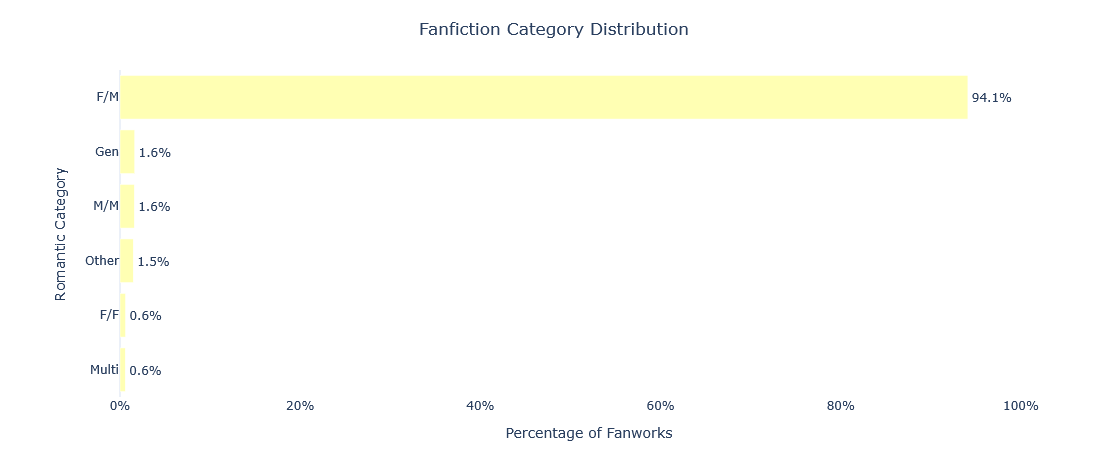

HTML figure already exists: E:\Jupyter_Programs\DH_Thesis\reports\fics_figures\07_category_distribution.html
PNG figure already exists: E:\Jupyter_Programs\DH_Thesis\reports\fics_figures\07_category_distribution.png


In [19]:
category_counts = (
    fics["romanticCategory"]
    .value_counts()
    .reset_index()
)

category_counts.columns = ["Category", "Count"]

category_counts["Percentage"] = (
    category_counts["Count"] / len(fics) * 100
)

# Sort ascending for horizontal bar
category_counts = category_counts.sort_values(
    "Percentage",
    ascending=True
)

fig = go.Figure(
    go.Bar(
        y=category_counts["Category"],
        x=category_counts["Percentage"],
        orientation="h",
        marker=dict(
            color="#ffffb3"
        ),
        text=[
            f"{x:.1f}%"
            for x in category_counts["Percentage"]
        ],
        textposition="outside",
        hovertemplate=
        "%{y}<br>%{x:.1f}% of corpus<extra></extra>"
    )
)

fig.update_layout(
    title=dict(
        text="Fanfiction Category Distribution",
        x=0.5
    ),
    xaxis_title="Percentage of Fanworks",
    yaxis_title="Romantic Category",
    template="plotly_white",
    height=450,
    width=800,
    margin=dict(
        l=120,
        r=50,
        t=70,
        b=50
    ),
    showlegend=False
)

fig.update_xaxes(
    showgrid=False,
    showline=False,
    ticksuffix="%",
    range=[0, category_counts["Percentage"].max() + 10]
)

fig.update_yaxes(
    showgrid=False,
    showline=False
)

fig.show()

save_plotly_figure(
    fig,
    "07_category_distribution",
    FICS_FIGURES_PATH
)

#### Data Decision: Retain all Romantic Categories

Along with F/M (Heterosexual), F/F and M/M (femslash or slash - homosexual)``Multi`` and ``Other`` categories were retained rather than collapsed or reassigned because their meanings are not sufficiently stable to support reliable recoding. While Multi may indicate polyamorous relationships, it can also refer to the presence of multiple relationship categories within a work (for example, a primary F/M relationship alongside a background relationship involving side characters). Similarly, Other is not limited to a single representational category; it may include non-binary characters, non-human relationships, or pairings that do not fit AO3’s predefined categories. As a result, further classification would require interpretive judgments that exceed the available metadata. To address the specific analytical interest in polyamorous relationship structures, polyship identification was therefore conducted separately through manual annotation and such records were removed rather than inferred from AO3’s broader category labels. Both categories were consequently preserved as distinct values to avoid introducing unsupported assumptions into the corpus analysis.

In [20]:
fics.columns

Index(['s', 'kudos', 'title', 'summary', 'datePublished', 'words', 'rating',
       'romanticCategory', 'publicationStatus', 'keyword', 'relationship',
       'polyship_human_flag', 'member', 'summary_length'],
      dtype='str')

In [21]:
#drop temporary columns
fics = fics.drop(columns=[
    "polyship_human_flag",
    "summary_length",
    "title_length"
], errors="ignore")

In [22]:
fics.columns

Index(['s', 'kudos', 'title', 'summary', 'datePublished', 'words', 'rating',
       'romanticCategory', 'publicationStatus', 'keyword', 'relationship',
       'member'],
      dtype='str')

BTS reader-insert summaries are generally concise paratextual descriptions, with most summaries providing only a brief premise or narrative hook. However, a small subset contains substantially longer plot descriptions, producing a positively skewed distribution.

For your clustering pipeline, this length analysis actually supports the argument that title + summary is a sparse and uneven paratextual representation, which is why fanfiction clustering may fragment more than chatbot metadata.

## 5. Canonical Tag Extraction

**Fanfiction tags** recorded here as ``keyword`` that are used to categorize fanworks as well as signal genres, genre conventions, tropes or content present a unique problem for masking. Firstly, we need to parse them individually into a list. Secondly, it is important to know the fanfiction archive that hosts this data, Archive of Our Own, (AO3) employs volunteers who organize and wrangle these tags in two ways: 

1. **Canonical Tags**:


Canonical tags are those tags in the fanfiction archive AO3 that can be searched and filtered using the autocomplete feature. These tags are the most unambiguous and accessible form of a tag which human tag wrangled assign in proper format to a same concept as its synonymous tags [(AO3 Tags FAQ)](https://archiveofourown.org/faq/tags?language_id=en#tagtypes). They follow detailed wrangling guidelines [(AO3 Wrangling Guidelines)](https://archiveofourown.org/wrangling_guidelines).  Usually, the character tags are written in alphabetical order by surname. 

2. **Non-Canonical Tags**:

On AO3, non-canonical tags are tags that have been created by users but have not been approved/merged into AO3's official tag system by tag wranglers.

From the [AO3 Selective Data Dump 2021](https://archiveofourown.org/admin_posts/18804), I have taken out a list of **Relationship** and **Canonical Freeform/Additional Tags** that can be used for categorizing canonical tags in two ways- (1) Freeform Tags (2) BTS-Related Freeform Tags. This categorization along with basic corpus stats and frequency analysis provides a way to categorize trope and genre related tags and tags with specific member names that need to masked at a later stage.


### 5.0 Separate BTS Member Canonical Tags and Other Canonical Tags

In [23]:
tag_df = load_file(METADATA_DIR / "ao3_data_dump_canonical_freeform_tags.csv")



canonical_tags = set(
    tag_df["freeform_tag"]
    .dropna()
    .astype(str)
    .str.strip()
)

tag_df.shape

(181014, 1)

In [24]:
tag_df["freeform_tag"] = (
    tag_df["freeform_tag"]
    .fillna("")
    .astype(str)
    .str.strip()
)

members = [
    "Jeon Jungkook",
    "Kim Taehyung",
    "Park Jimin",
    "Kim Namjoon",
    "Jung Hoseok",
    "Min Yoongi",
    "Kim Seokjin",
    "Jungkook",
    "Jimin",
    "Taehyung",
    "Namjoon",
    "Seokjin"
]

member_pattern = "|".join(
    re.escape(name) for name in members
)

# Identify member-related tags
member_mask = (
    tag_df["freeform_tag"]
    .str.contains(
        member_pattern,
        case=False,
        regex=True,
        na=False
    )
)

# Extract member tags into separate dataframe
member_tag_df = tag_df[member_mask].copy()

# Keep only non-member tags
tag_df = tag_df[~member_mask].copy()

# Remove empty freeform tags
tag_df = tag_df[
    tag_df["freeform_tag"].str.len() > 0
].reset_index(drop=True)

member_tag_df = member_tag_df.reset_index(drop=True)

print(f"Removed member-related tags: {len(member_tag_df)}")
print(f"Remaining freeform tags: {len(tag_df)}")

tag_df.to_csv(
    METADATA_DIR / "canonical_freeform_tags.csv",
    index=False
)

member_tag_df.to_csv(
    METADATA_DIR / "canonical_freeform_bts_tags.csv",
    index=False
)

Removed member-related tags: 4474
Remaining freeform tags: 173207


### 5.1 Parsing Tags in a List

In [25]:
#parse tags into a list 

def parse_tags(raw):
    if pd.isna(raw) or str(raw).strip().lower() == "nan":
        return []
    return [t.strip() for t in str(raw).split("|") if t.strip()]
 
 



In [26]:
fics["tag_list"] = fics["keyword"].apply(parse_tags)

print(f"Tag lists of {len(fics):,} fanfictions processed.")

Tag lists of 6,668 fanfictions processed.


### 5.2 Loading Canonical Tags from AO3

In [27]:
#load canonical tags list - both general freeform and bts-specific freeform tags
canonical_tags = set(
    load_file(METADATA_DIR / "canonical_freeform_tags.csv")["freeform_tag"]
    .dropna()
    .astype(str)
    .str.strip()
)

bts_tags = set(
    load_file(METADATA_DIR / "canonical_freeform_bts_tags.csv")["freeform_tag"]
    .dropna()
    .astype(str)
    .str.strip()
)

print(f"{len(canonical_tags):,} canonical AO3 tags loaded.")
print(f"{len(bts_tags):,} BTS canonical tags loaded.")

173,207 canonical AO3 tags loaded.
4,474 BTS canonical tags loaded.


### 5.3 Filtering Canonical, Non-Canonical and BTS Tags in the BTS Reader-Insert Fanfiction Dataset

Non-canonical tags refer to user-generated AO3 tags that were not included in the predefined canonical tag set or BTS-specific tag set. These tags were retained when they met filtering criteria of not more than 4 tokens to prioritize concise and interpretable descriptors: tags were limited to four words or fewer, excluded fully capitalized expressions, and retained title-case phrases consistent with AO3’s descriptive tagging conventions. This filtering was applied to reduce noise from excessively long tags, which often function as personal commentary, conversational notes, or highly specific authorial remarks rather than broadly comparable narrative descriptors. While these criteria are heuristic, they provide a consistent method for identifying non-canonical tags likely to contribute meaningful information about tropes, themes, and narrative structures.

In [28]:
# Extract canonical and BTS-specific tags

fics["canonical_tags"] = fics["tag_list"].apply(
    lambda tags: [
        tag for tag in tags
        if tag in canonical_tags
    ]
)

fics["bts_tags"] = fics["tag_list"].apply(
    lambda tags: [
        tag for tag in tags
        if tag in bts_tags
    ]
)


# Treat canonical and BTS-specific tags as the canonical tag vocabulary

all_canonical_tags = canonical_tags | bts_tags


# Extract all non-canonical tags

fics["noncanonical_tags"] = fics["tag_list"].apply(
    lambda tags: [
        tag for tag in tags
        if tag not in all_canonical_tags
    ]
)


# Extract filtered non-canonical tags for characterization analysis

fics["filtered_noncanonical_tags"] = fics["tag_list"].apply(
    lambda tags: [
        tag for tag in tags
        if (
            tag not in all_canonical_tags
            and len(
                re.findall(
                    r"[A-Za-z]+",
                    str(tag)
                )
            ) <= 4
            and str(tag) != str(tag).upper()
            and all(
                word[0].isupper()
                for word in re.findall(
                    r"[A-Za-z]+",
                    str(tag)
                )
                if word
            )
        )
    ]
)

### 5.4  Tags Frequency 

In [29]:
#count tags in bts reader-insert corpus 
all_counter = Counter(
    tag
    for tags in fics["tag_list"]
    for tag in tags
)

canonical_counter = Counter(
    tag
    for tags in fics["canonical_tags"]
    for tag in tags
)

noncanonical_counter = Counter(
    tag
    for tags in fics["noncanonical_tags"]
    for tag in tags
)

filtered_noncanonical_counter = Counter(
    tag
    for tags in fics["filtered_noncanonical_tags"]
    for tag in tags
)

bts_counter = Counter(
    tag
    for tags in fics["bts_tags"]
    for tag in tags
)


In [30]:
stats = pd.DataFrame({
    "Category": [
        "Canonical Tags",
        "BTS Canonical Tags",
        "Non-Canonical Tags"
    ],
    "Unique Tags": [
        len(canonical_counter),
        len(bts_counter),
        len(noncanonical_counter)
    ],
    "Total Occurrences": [
        sum(canonical_counter.values()),
        sum(bts_counter.values()),
        sum(noncanonical_counter.values())
    ]
})


# Save tag frequency report

TAG_FREQ_REPORT = (
    FICS_REPORTS_PATH /
    "03_canon_noncanon_tag_freq.md"
)

markdown_content = """# Canonical and Non-Canonical Tag Frequency


""" + stats.to_markdown(
    index=False
)


# Save only if the report does not already exist

if TAG_FREQ_REPORT.exists():

    print(
        f"Tag frequency report already exists: "
        f"{TAG_FREQ_REPORT}"
    )

else:

    TAG_FREQ_REPORT.write_text(
        markdown_content,
        encoding="utf-8"
    )

    print(
        f"Saved tag frequency report: "
        f"{TAG_FREQ_REPORT}"
    )


# Display report

display(
    Markdown(markdown_content)
)

Tag frequency report already exists: E:\Jupyter_Programs\DH_Thesis\reports\fics_reports\03_canon_noncanon_tag_freq.md


# Canonical and Non-Canonical Tag Frequency


| Category           |   Unique Tags |   Total Occurrences |
|:-------------------|--------------:|--------------------:|
| Canonical Tags     |          3021 |               36726 |
| BTS Canonical Tags |           315 |                1644 |
| Non-Canonical Tags |         13675 |               24770 |

In [31]:
# Combine full names and stage names by BTS member

member_aliases = {
    "Jungkook": [
        "Jeon Jungkook",
        "Jungkook"
    ],
    "Taehyung": [
        "Kim Taehyung",
        "Taehyung"
    ],
    "Jimin": [
        "Park Jimin",
        "Jimin"
    ],
    "Namjoon": [
        "Kim Namjoon",
        "Namjoon"
    ],
    "Hoseok": [
        "Jung Hoseok",
        "Hoseok"
    ],
    "Yoongi": [
        "Min Yoongi",
        "Yoongi"
    ],
    "Seokjin": [
        "Kim Seokjin",
        "Seokjin",
        "Jin"
    ]
}


# Count tag occurrences by BTS member

member_mentions = {
    member: sum(
        count
        for tag, count in bts_counter.items()
        if any(
            alias.lower() in tag.lower()
            for alias in aliases
        )
    )
    for member, aliases in member_aliases.items()
}


member_mentions_df = (
    pd.DataFrame(
        member_mentions.items(),
        columns=["Member", "Occurrences"]
    )
    .sort_values(
        "Occurrences",
        ascending=False
    )
    .reset_index(drop=True)
)


# Save report

MEMBER_TAG_FREQ_REPORT = (
    FICS_REPORTS_PATH /
    "04_tag_freq_per_member.md"
)

markdown_content = """# BTS Member Tag Frequency

The table summarizes the total occurrences of BTS member names and
aliases within the BTS-specific tag set. Stage names and full names are
combined under their respective BTS member.

""" + member_mentions_df.to_markdown(
    index=False
)


# Save only if the report does not already exist

if MEMBER_TAG_FREQ_REPORT.exists():

    print(
        f"Member tag frequency report already exists: "
        f"{MEMBER_TAG_FREQ_REPORT}"
    )

else:

    MEMBER_TAG_FREQ_REPORT.write_text(
        markdown_content,
        encoding="utf-8"
    )

    print(
        f"Saved member tag frequency report: "
        f"{MEMBER_TAG_FREQ_REPORT}"
    )


# Display report

display(
    Markdown(markdown_content)
)

Member tag frequency report already exists: E:\Jupyter_Programs\DH_Thesis\reports\fics_reports\04_tag_freq_per_member.md


# BTS Member Tag Frequency

The table summarizes the total occurrences of BTS member names and
aliases within the BTS-specific tag set. Stage names and full names are
combined under their respective BTS member.

| Member   |   Occurrences |
|:---------|--------------:|
| Jungkook |          1194 |
| Jimin    |           464 |
| Taehyung |             0 |
| Namjoon  |             0 |
| Hoseok   |             0 |
| Yoongi   |             0 |
| Seokjin  |             0 |

In [32]:
# Count filtered non-canonical tag occurrences by BTS member

member_mentions_filtered = {
    member: sum(
        count
        for tag, count in filtered_noncanonical_counter.items()
        if any(
            alias.lower() in tag.lower()
            for alias in aliases
        )
    )
    for member, aliases in member_aliases.items()
}


member_mentions_filtered_df = (
    pd.DataFrame(
        member_mentions_filtered.items(),
        columns=["Member", "Occurrences"]
    )
    .sort_values(
        "Occurrences",
        ascending=False
    )
    .reset_index(drop=True)
)


# Save report

FILTERED_MEMBER_TAG_FREQ_REPORT = (
    FICS_REPORTS_PATH /
    "05_noncanonicaltag_freq_per_member.md"
)

markdown_content = """# Filtered Non-Canonical Tag Frequency by BTS Member

The table summarizes the occurrences of BTS member names and aliases
within the filtered non-canonical tag set. Stage names and full names
are combined under their respective BTS member.

""" + member_mentions_filtered_df.to_markdown(
    index=False
)


# Save only if the report does not already exist

if FILTERED_MEMBER_TAG_FREQ_REPORT.exists():

    print(
        f"Filtered member tag frequency report already exists: "
        f"{FILTERED_MEMBER_TAG_FREQ_REPORT}"
    )

else:

    FILTERED_MEMBER_TAG_FREQ_REPORT.write_text(
        markdown_content,
        encoding="utf-8"
    )

    print(
        f"Saved filtered member tag frequency report: "
        f"{FILTERED_MEMBER_TAG_FREQ_REPORT}"
    )


# Display report

display(
    Markdown(markdown_content)
)

Filtered member tag frequency report already exists: E:\Jupyter_Programs\DH_Thesis\reports\fics_reports\05_noncanonicaltag_freq_per_member.md


# Filtered Non-Canonical Tag Frequency by BTS Member

The table summarizes the occurrences of BTS member names and aliases
within the filtered non-canonical tag set. Stage names and full names
are combined under their respective BTS member.

| Member   |   Occurrences |
|:---------|--------------:|
| Yoongi   |           889 |
| Seokjin  |           774 |
| Taehyung |           702 |
| Namjoon  |           559 |
| Hoseok   |           487 |
| Jimin    |           254 |
| Jungkook |           222 |

While member-specific canonical tags offer valuable insight into how fans collectively imagine individual members, they were not included in the network analysis because their frequency is closely tied to member popularity with the reader-insert subgenre that could unevenly skew the resulting networks. Instead, this study focused on broader genre and trope-related tags and noncanonical member tags to examine shared narrative conventions and member-specific characterization across BTS reader-insert fanfiction.

### 5.5 Raw Frequency Analysis of Top Tags

In [33]:
#frequency analysis
def counter_to_df(counter, n=50):

    return (
        pd.DataFrame(
            counter.most_common(n),
            columns=["Tag", "Frequency"]
        )
    )

In [34]:
# Top 50 tags in the corpus

top_50_tags = counter_to_df(all_counter).head(50)

TOP_TAGS_REPORT = (
    FICS_REPORTS_PATH /
    "06_top_50_all_tags.md"
)

markdown_content = """# Top 50 Tags in the Corpus

The table presents the 50 most frequent tags across the BTS
reader-insert fanfiction corpus.

""" + top_50_tags.to_markdown(
    index=False
)


# Save only if the report does not already exist

if TOP_TAGS_REPORT.exists():

    print(
        f"Top 50 tags report already exists: "
        f"{TOP_TAGS_REPORT}"
    )

else:

    TOP_TAGS_REPORT.write_text(
        markdown_content,
        encoding="utf-8"
    )

    print(
        f"Saved top 50 tags report: "
        f"{TOP_TAGS_REPORT}"
    )


# Display report

display(
    Markdown(markdown_content)
)

Top 50 tags report already exists: E:\Jupyter_Programs\DH_Thesis\reports\fics_reports\06_top_50_all_tags.md


# Top 50 Tags in the Corpus

The table presents the 50 most frequent tags across the BTS
reader-insert fanfiction corpus.

| Tag                                     |   Frequency |
|:----------------------------------------|------------:|
| Fluff                                   |        1781 |
| Smut                                    |        1564 |
| Angst                                   |        1065 |
| Oral Sex                                |         841 |
| Suga                                    |         557 |
| Dirty Talk                              |         459 |
| Romance                                 |         448 |
| Vaginal Fingering                       |         445 |
| Fluff and Smut                          |         411 |
| V                                       |         410 |
| Vaginal Sex                             |         401 |
| Established Relationship                |         375 |
| Friends to Lovers                       |         361 |
| Reader-Insert                           |         357 |
| J-Hope                                  |         332 |
| Fluff and Angst                         |         328 |
| Rough Sex                               |         304 |
| Alternate Universe - College/University |         302 |
| RM                                      |         297 |
| Jin                                     |         277 |
| Sex                                     |         273 |
| Explicit Sexual Content                 |         270 |
| One Shot                                |         263 |
| Unprotected Sex                         |         247 |
| Alternate Universe                      |         243 |
| Creampie                                |         236 |
| Eventual Smut                           |         216 |
| Slow Burn                               |         215 |
| Min Yoongi                              |         206 |
| Plot What Plot/Porn Without Plot        |         204 |
| Multiple Orgasms                        |         203 |
| Domestic Fluff                          |         200 |
| Spanking                                |         199 |
| Dom/sub                                 |         197 |
| bts - Freeform                          |         194 |
| Masturbation                            |         182 |
| Blow Jobs                               |         182 |
| Drabble                                 |         182 |
| Explicit Language                       |         180 |
| Kim Taehyung                            |         180 |
| Light Angst                             |         179 |
| Semi-Public Sex                         |         179 |
| Kissing                                 |         175 |
| Cunnilingus                             |         173 |
| Daddy Kink                              |         165 |
| Praise Kink                             |         163 |
| Angst with a Happy Ending               |         159 |
| Overstimulation                         |         153 |
| Shameless Smut                          |         149 |
| Fingering                               |         147 |

In [35]:
# Top 50 canonical freeform tags

top_50_canonical_tags = counter_to_df(
    canonical_counter
).head(50)

TOP_CANONICAL_TAGS_REPORT = (
    FICS_REPORTS_PATH /
    "07_top_50_canonical_tags.md"
)

markdown_content = """# Top 50 Canonical Freeform Tags

The table presents the 50 most frequent canonical freeform tags in the
BTS reader-insert fanfiction corpus.

""" + top_50_canonical_tags.to_markdown(
    index=False
)


# Save only if the report does not already exist

if TOP_CANONICAL_TAGS_REPORT.exists():

    print(
        f"Top 50 canonical tags report already exists: "
        f"{TOP_CANONICAL_TAGS_REPORT}"
    )

else:

    TOP_CANONICAL_TAGS_REPORT.write_text(
        markdown_content,
        encoding="utf-8"
    )

    print(
        f"Saved top 50 canonical tags report: "
        f"{TOP_CANONICAL_TAGS_REPORT}"
    )


# Display report

display(
    Markdown(markdown_content)
)

Top 50 canonical tags report already exists: E:\Jupyter_Programs\DH_Thesis\reports\fics_reports\07_top_50_canonical_tags.md


# Top 50 Canonical Freeform Tags

The table presents the 50 most frequent canonical freeform tags in the
BTS reader-insert fanfiction corpus.

| Tag                                     |   Frequency |
|:----------------------------------------|------------:|
| Fluff                                   |        1781 |
| Smut                                    |        1564 |
| Angst                                   |        1065 |
| Oral Sex                                |         841 |
| Dirty Talk                              |         459 |
| Romance                                 |         448 |
| Vaginal Fingering                       |         445 |
| Fluff and Smut                          |         411 |
| Vaginal Sex                             |         401 |
| Established Relationship                |         375 |
| Friends to Lovers                       |         361 |
| Reader-Insert                           |         357 |
| Fluff and Angst                         |         328 |
| Rough Sex                               |         304 |
| Alternate Universe - College/University |         302 |
| Sex                                     |         273 |
| Explicit Sexual Content                 |         270 |
| One Shot                                |         263 |
| Alternate Universe                      |         243 |
| Creampie                                |         236 |
| Eventual Smut                           |         216 |
| Slow Burn                               |         215 |
| Plot What Plot/Porn Without Plot        |         204 |
| Multiple Orgasms                        |         203 |
| Domestic Fluff                          |         200 |
| Spanking                                |         199 |
| Dom/sub                                 |         197 |
| Masturbation                            |         182 |
| Blow Jobs                               |         182 |
| Drabble                                 |         182 |
| Explicit Language                       |         180 |
| Light Angst                             |         179 |
| Semi-Public Sex                         |         179 |
| Kissing                                 |         175 |
| Cunnilingus                             |         173 |
| Daddy Kink                              |         165 |
| Praise Kink                             |         163 |
| Angst with a Happy Ending               |         159 |
| Overstimulation                         |         153 |
| Shameless Smut                          |         149 |
| Choking                                 |         146 |
| Swearing                                |         145 |
| Teasing                                 |         143 |
| Enemies to Lovers                       |         138 |
| Love                                    |         135 |
| Violence                                |         119 |
| Humor                                   |         119 |
| Strangers to Lovers                     |         117 |
| Light Dom/sub                           |         114 |
| Nipple Play                             |         111 |

In [36]:
# Top 50 filtered non-canonical BTS freeform tags

top_50_filtered_noncanonical_tags = counter_to_df(
    filtered_noncanonical_counter
).head(50)

TOP_FILTERED_NONCANONICAL_TAGS_REPORT = (
    FICS_REPORTS_PATH /
    "08_top_50_noncanonical_bts_tags.md"
)

markdown_content = """# Top 50 Non-Canonical BTS Freeform Tags

The table presents the 50 most frequent filtered non-canonical BTS
freeform tags in the reader-insert fanfiction corpus.

""" + top_50_filtered_noncanonical_tags.to_markdown(
    index=False
)


# Save only if the report does not already exist

if TOP_FILTERED_NONCANONICAL_TAGS_REPORT.exists():

    print(
        f"Top 50 non-canonical BTS tags report already exists: "
        f"{TOP_FILTERED_NONCANONICAL_TAGS_REPORT}"
    )

else:

    TOP_FILTERED_NONCANONICAL_TAGS_REPORT.write_text(
        markdown_content,
        encoding="utf-8"
    )

    print(
        f"Saved top 50 non-canonical BTS tags report: "
        f"{TOP_FILTERED_NONCANONICAL_TAGS_REPORT}"
    )


# Display report

display(
    Markdown(markdown_content)
)

Top 50 non-canonical BTS tags report already exists: E:\Jupyter_Programs\DH_Thesis\reports\fics_reports\08_top_50_noncanonical_bts_tags.md


# Top 50 Non-Canonical BTS Freeform Tags

The table presents the 50 most frequent filtered non-canonical BTS
freeform tags in the reader-insert fanfiction corpus.

| Tag                   |   Frequency |
|:----------------------|------------:|
| Suga                  |         557 |
| J-Hope                |         332 |
| Jin                   |         277 |
| Unprotected Sex       |         247 |
| Min Yoongi            |         206 |
| Kim Taehyung          |         180 |
| Fingering             |         147 |
| Kim Namjoon           |         142 |
| Kim Seokjin           |          94 |
| Jung Hoseok           |          83 |
| Squirting             |          70 |
| Degradation           |          68 |
| Oneshot               |          67 |
| Oral                  |          63 |
| Soft Min Yoongi       |          62 |
| Edging                |          56 |
| Mafia AU              |          46 |
| College AU            |          46 |
| Mommy Kink            |          44 |
| Penetrative Sex       |          43 |
| Suga Is Whipped       |          43 |
| Dom Jung Hoseok       |          41 |
| Sweet Kim Seokjin     |          40 |
| Cute Min Yoongi       |          38 |
| Reader Insert         |          37 |
| Top Kim Taehyung      |          33 |
| Dom Kim Taehyung      |          32 |
| Cum Play              |          32 |
| Dancer Jung Hoseok    |          31 |
| Dom Kim Namjoon       |          31 |
| Sweet Kim Namjoon     |          30 |
| Cum Eating            |          30 |
| Cute Kim Taehyung     |          30 |
| Impregnation Kink     |          29 |
| Female Reader         |          29 |
| Sub Min Yoongi        |          28 |
| Dom Kim Seokjin       |          28 |
| Producer Min Yoongi   |          27 |
| Dom Min Yoongi        |          27 |
| Cute Jung Hoseok      |          27 |
| Cumplay               |          26 |
| Yandere Bangtan Boys  |          26 |
| Min Yoongi - Freeform |          26 |
| Grumpy Min Yoongi     |          24 |
| Idol Min Yoongi       |          24 |
| Hybrid AU             |          23 |
| Jeon Jungkook-Centric |          22 |
| Scenario              |          22 |
| Adorable Kim Taehyung |          21 |
| Protected Sex         |          21 |

#### Data Decision: Analyze Only Canonical AO3 Tags in Co-Occurence Networks 

Comparing the most frequent tags showed that non-canonical tags reflect the varied ways fans describe their works, including alternative names, spelling variations, and individualized descriptions of characters, scenarios, and relationships. Since these tags vary in form and specificity, the primary co-occurrence analysis uses canonical freeform tags, which provide a more consistent vocabulary through AO3’s tag-wrangling system. Filtered non-canonical BTS tags are used separately for a secondary co-occurrence analysis to examine how individual members are characterized through fan-created tags in the reader-insert corpus.

### 5.7 Canonical Tags Distribution Across Ratings

In [37]:
def count_tags_by_rating(df, tag_column):

    rating_counts = {}

    for rating in sorted(df["rating"].dropna().unique()):

        subset = df[df["rating"] == rating]

        counter = Counter()

        for tags in subset[tag_column]:
            counter.update(tags)

        rating_counts[rating] = counter

    return rating_counts

In [38]:
rating_canonical = count_tags_by_rating(fics, "canonical_tags")

In [39]:
def plot_rating_wordclouds(df, tag_column, title):

    ratings = [
        "General Audiences",
        "Teen And Up Audiences",
        "Mature",
        "Explicit"
    ]

    fig, axes = plt.subplots(2,2,figsize=(14,10))
    axes = axes.flatten()

    for ax, rating in zip(axes, ratings):

        subset = df[df["rating"] == rating]

        counter = Counter()

        for tags in subset[tag_column]:
            counter.update(tags)

        wc = WordCloud(
            width=700,
            height=700,
            background_color="white",
            colormap="viridis",
            max_words=30,
            random_state=42
        ).generate_from_frequencies(dict(counter.most_common(50)))

        ax.imshow(wc)
        ax.axis("off")
        ax.set_title(rating)

    plt.suptitle(title)
    
    plt.tight_layout()
    plt.savefig(
    "rating_wordclouds.pdf",
    bbox_inches="tight"
)
    plt.show()

In [40]:
def top_tags_by_rating(df, tag_column, n=30):

    ratings = [
        "General Audiences",
        "Teen And Up Audiences",
        "Mature",
        "Explicit"
    ]

    results = {}

    for rating in ratings:

        subset = df[df["rating"] == rating]

        counter = Counter()

        for tags in subset[tag_column]:
            counter.update(tags)

        results[rating] = (
            pd.DataFrame(
                counter.most_common(n),
                columns=["Tag", "Frequency"]
            )
        )

    return results

In [41]:
canonical_top30_rating = top_tags_by_rating(
    fics,
    "canonical_tags",
    n=30
)



In [42]:
# Save canonical tag wordclouds by rating

CANON_TAGS_RATING_FIGURE = (
    FICS_FIGURES_PATH /
    "08_canontags_per_ratings.png"
)

if CANON_TAGS_RATING_FIGURE.exists():

    print(
        f"Figure already exists: {CANON_TAGS_RATING_FIGURE}"
    )

else:

    plot_rating_wordclouds(
        fics,
        "canonical_tags",
        "Top Canonical Tags by Rating"
    )

    # Save the current matplotlib figure
    plt.savefig(
        CANON_TAGS_RATING_FIGURE,
        dpi=300,
        bbox_inches="tight"
    )

    print(
        f"Saved figure: {CANON_TAGS_RATING_FIGURE}"
    )

    plt.show()

Figure already exists: E:\Jupyter_Programs\DH_Thesis\reports\fics_figures\08_canontags_per_ratings.png


Comparing tag frequencies across ratings reveals distinct narrative conventions associated with different rating categories. In General Audiences and Teen And Up Audiences works, canonical tags foreground affective and romantic storytelling, with Fluff, Angst, Romance, Friends to Lovers, Domestic Fluff, and Established Relationship appearing prominently. Mature and Explicit works, however, foreground erotic conventions through tags such as Smut, Oral Sex, Dirty Talk, Vaginal Sex, and Explicit Sexual Content. At the same time, romantic and emotional tropes continue to thread through higher-rated works, suggesting that sexual content is often interwoven with existing narratives of intimacy and relationship development rather than displacing them.


In [43]:
fics.columns

Index(['s', 'kudos', 'title', 'summary', 'datePublished', 'words', 'rating',
       'romanticCategory', 'publicationStatus', 'keyword', 'relationship',
       'member', 'tag_list', 'canonical_tags', 'bts_tags', 'noncanonical_tags',
       'filtered_noncanonical_tags'],
      dtype='str')

In [44]:

# Reorder columns
fics = fics[
    [
        # Basic metadata
        "s",
        "title",
        "summary",
        "datePublished",
        "words",
        "rating",
        "romanticCategory",
        "publicationStatus",
        "kudos",
        "member",

        # Original tags
        "keyword",
        "relationship",
        "tag_list",
        "canonical_tags",
        "noncanonical_tags",
        "filtered_noncanonical_tags",
        "bts_tags",
    ]
]

In [45]:
fics.columns

Index(['s', 'title', 'summary', 'datePublished', 'words', 'rating',
       'romanticCategory', 'publicationStatus', 'kudos', 'member', 'keyword',
       'relationship', 'tag_list', 'canonical_tags', 'noncanonical_tags',
       'filtered_noncanonical_tags', 'bts_tags'],
      dtype='str')

In [46]:
# Identify works with no AO3 canonical freeform tags

no_canonical_freeform = fics[
    fics["canonical_tags"].apply(lambda x: x == [])
].copy()


def tag_composition(row):

    has_bts_tags = len(row["bts_tags"]) > 0
    has_noncanonical_tags = len(row["noncanonical_tags"]) > 0

    if has_bts_tags and has_noncanonical_tags:
        return "BTS-Specific + Non-Canonical Tags"

    elif has_bts_tags:
        return "BTS-Specific Tags"

    elif has_noncanonical_tags:
        return "Non-Canonical Tags"

    else:
        return "No Other Tags"


# Classify works by their remaining tag composition

no_canonical_freeform["tag_composition"] = (
    no_canonical_freeform.apply(
        tag_composition,
        axis=1
    )
)


# Count works in each composition

counts = (
    no_canonical_freeform["tag_composition"]
    .value_counts()
    .rename_axis("Tag Composition")
    .reset_index(name="Number of Fanfiction Works")
)


print(
    "Works with no AO3 canonical freeform tags:",
    len(no_canonical_freeform)
)

display(counts)

Works with no AO3 canonical freeform tags: 722


,Tag Composition,Number of Fanfiction Works
0,No Other Tags,367
1,Non-Canonical Tags,306
2,BTS-Specific + Non-Canonical Tags,33
3,BTS-Specific Tags,16


In [47]:
fics.shape

(6668, 17)

## 6. Save Cleaned Data

In [48]:
def save_data(
    df: pd.DataFrame,
    out_path: Path = None,
    group_col: str = None,
    out_dir: Path = None,
    suffix: str = ""
):
    """
    Save a dataframe as either a single CSV file or multiple
    CSV files grouped by a column.

    Existing single files are confirmed individually.
    Existing grouped files are confirmed once for all files.
    """

    def confirm_overwrite(message: str) -> bool:
        """Ask whether existing files should be overwritten."""

        while True:

            response = input(
                f"{message}\nOverwrite? (y/n): "
            ).strip().lower()

            if response in ["y", "yes"]:
                return True

            if response in ["n", "no"]:
                return False

            print("Please enter 'y' or 'n'.")


    # Save full dataframe

    if out_path is not None:

        out_path.parent.mkdir(
            parents=True,
            exist_ok=True
        )

        if out_path.exists():

            overwrite = confirm_overwrite(
                f"\nFile already exists:\n{out_path}"
            )

            if not overwrite:

                print(
                    f"Skipped: {out_path}"
                )

                return

        df.to_csv(
            out_path,
            index=False
        )

        print(
            f"Saved: {out_path}"
        )

        return


    # Save grouped dataframes

    if group_col is not None:

        if out_dir is None:

            raise ValueError(
                "out_dir must be provided "
                "when using group_col"
            )

        out_dir.mkdir(
            parents=True,
            exist_ok=True
        )


        # Check whether any member files already exist

        grouped_paths = [
            out_dir /
            f"{str(key).lower()}_{suffix}.csv"
            for key in df[group_col].dropna().unique()
        ]

        existing_paths = [
            path for path in grouped_paths
            if path.exists()
        ]


        # Ask once whether to overwrite all existing files

        overwrite_all = True

        if existing_paths:

            overwrite_all = confirm_overwrite(
                "\nExisting grouped files found:\n"
                + "\n".join(
                    str(path)
                    for path in existing_paths
                )
                + "\n\nOverwrite all existing member files?"
            )


        # Save or skip grouped files

        for key, subdf in df.groupby(group_col):

            file_name = (
                f"{str(key).lower()}_{suffix}.csv"
            )

            path = out_dir / file_name


            if path.exists() and not overwrite_all:

                print(
                    f"Skipped existing: {path}"
                )

                continue


            subdf.to_csv(
                path,
                index=False
            )

            print(
                f"Saved: {path}"
            )

        return


    raise ValueError(
        "Either out_path or group_col "
        "must be provided"
    )

In [49]:
# Save combined corpus

save_data(
    fics,
    out_path=(
        CLEAN_FICS_PATH /
        "bts_all_member_fics_masked.csv"
    )
)


# Save member-specific corpora

save_data(
    fics,
    group_col="member",
    out_dir=CLEAN_FICS_PATH,
    suffix="fics_masked"
)


File already exists:
E:\Jupyter_Programs\DH_Thesis\data\cleaned\fics\bts_all_member_fics_masked.csv
Overwrite? (y/n):  n


Skipped: E:\Jupyter_Programs\DH_Thesis\data\cleaned\fics\bts_all_member_fics_masked.csv



Existing grouped files found:
E:\Jupyter_Programs\DH_Thesis\data\cleaned\fics\jungkook_fics_masked.csv
E:\Jupyter_Programs\DH_Thesis\data\cleaned\fics\yoongi_fics_masked.csv
E:\Jupyter_Programs\DH_Thesis\data\cleaned\fics\jimin_fics_masked.csv
E:\Jupyter_Programs\DH_Thesis\data\cleaned\fics\hoseok_fics_masked.csv
E:\Jupyter_Programs\DH_Thesis\data\cleaned\fics\taehyung_fics_masked.csv
E:\Jupyter_Programs\DH_Thesis\data\cleaned\fics\namjoon_fics_masked.csv
E:\Jupyter_Programs\DH_Thesis\data\cleaned\fics\seokjin_fics_masked.csv

Overwrite all existing member files?
Overwrite? (y/n):  n


Skipped existing: E:\Jupyter_Programs\DH_Thesis\data\cleaned\fics\hoseok_fics_masked.csv
Skipped existing: E:\Jupyter_Programs\DH_Thesis\data\cleaned\fics\jimin_fics_masked.csv
Skipped existing: E:\Jupyter_Programs\DH_Thesis\data\cleaned\fics\jungkook_fics_masked.csv
Skipped existing: E:\Jupyter_Programs\DH_Thesis\data\cleaned\fics\namjoon_fics_masked.csv
Skipped existing: E:\Jupyter_Programs\DH_Thesis\data\cleaned\fics\seokjin_fics_masked.csv
Skipped existing: E:\Jupyter_Programs\DH_Thesis\data\cleaned\fics\taehyung_fics_masked.csv
Skipped existing: E:\Jupyter_Programs\DH_Thesis\data\cleaned\fics\yoongi_fics_masked.csv
